# Module 17 - Credit Score Project - Part 1: Data Processing

This is the first phase of a Credit Score prediction project, focusing on data preprocessing techniques learned throughout the course.

The **credit score** is a numerical score representing an individual's creditworthiness based on financial history, debt levels, credit duration, and types of credit used. [file:1]

**Project Goal**: Build a model to predict default risk (inadimplência) for financial institutions, enabling better credit approval decisions. Note: This uses a banking dataset different from class examples (which focused on churn prediction); here, we target credit score estimation.

In [23]:
# Essential libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [24]:
# Load the dataset
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


# Step 1: Data Preprocessing

**A) Check the data types of each column and convert them if necessary**


In [25]:
# Checking the data types of the columns
df.dtypes

,0
Age,float64
Gender,object
Income,object
Education,object
Marital Status,object
Number of Children,int64
Home Ownership,object
Credit Score,object


In [26]:
# Convert the 'Income' variable to float.
# This column represents annual salary but is currently stored as an object (string).

df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '.', regex=False)
df['Income'] = df['Income'].astype(float)

# Check data types again
df.dtypes

,0
Age,float64
Gender,object
Income,float64
Education,object
Marital Status,object
Number of Children,int64
Home Ownership,object
Credit Score,object


**B) Check if there are columns with missing values. If there are missing values, handle them by either removing or replacing them. Justify the chosen approach.**

In [27]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Age,34
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


In [28]:
# The 'Age' column contains missing values.
# We replace them with the mean age to preserve the overall distribution
# and avoid losing data by removing rows.

df['Age'] = df['Age'].fillna(df['Age'].mean())

# Verify that there are no remaining missing values
df.isnull().sum()

,0
Age,0
Gender,0
Income,0
Education,0
Marital Status,0
Number of Children,0
Home Ownership,0
Credit Score,0


**C) Check if there are incorrectly entered values in the categorical variables that may require cleaning.**

In [29]:
# Check unique values in categorical columns
# This helps detect typing errors

print("Gender:", df['Gender'].unique())
print("Education:", df['Education'].unique())
print("Marital Status:", df['Marital Status'].unique())
print("Home Ownership:", df['Home Ownership'].unique())
print("Credit Score:", df['Credit Score'].unique())

Gender: ['Female' 'Male']
Education: ["Bachelor's Degree" "Master's Degree" 'Doctorate' 'High School Diploma'
 "Associate's Degree"]
Marital Status: ['Single' 'Married']
Home Ownership: ['Rented' 'Owned']
Credit Score: ['High' 'Average' 'Low']


# Exploratory Data Analysis (EDA).

**A) Numerical Variables.**

In [30]:
# Summary statistics for numerical variables
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.507692,83765.243902,0.652439
std,7.561808,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,31.750000,57500.000000,0.000000
50%,37.507692,83750.000000,0.000000
75%,43.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


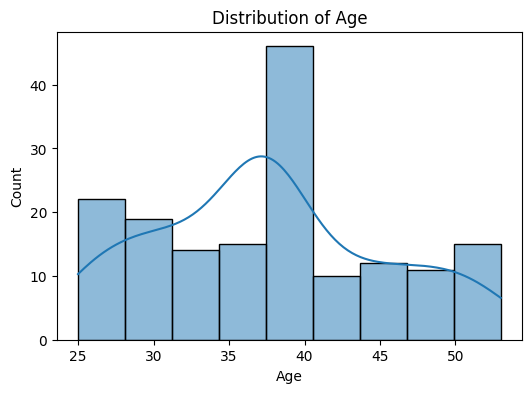

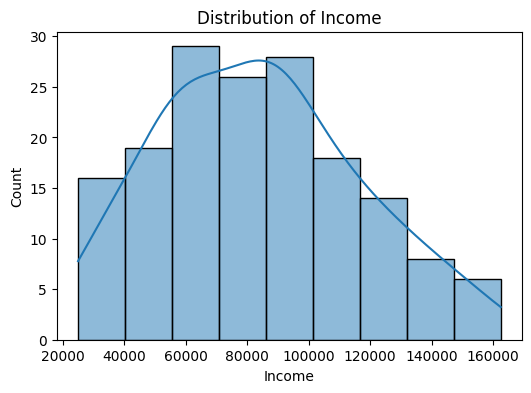

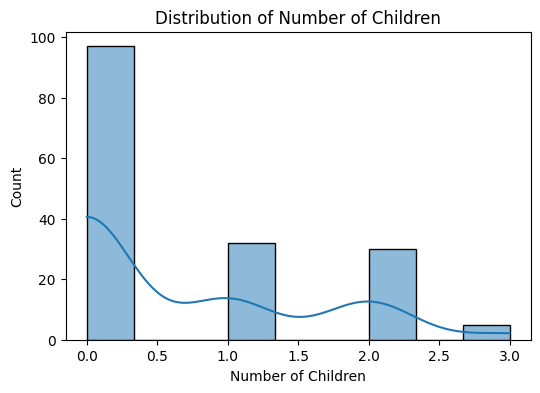

In [31]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

# Plot histogram for each numerical variable
for col in numerical_cols:

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')
    plt.show()

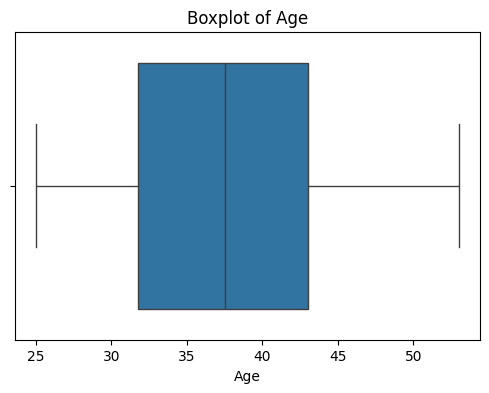

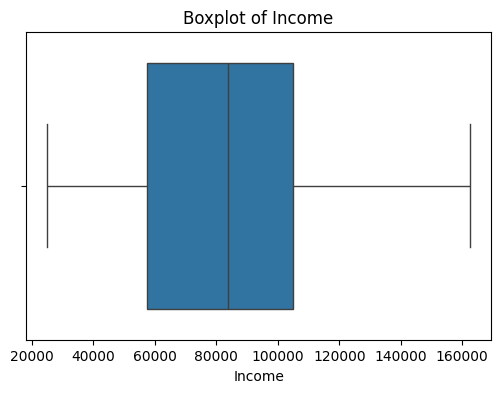

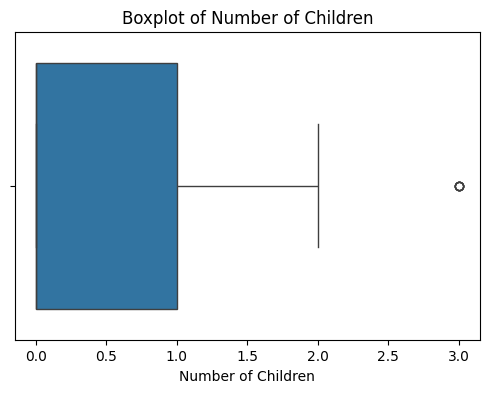

In [32]:
# Boxplots help detect extreme values

for col in numerical_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')
    plt.show()

We observe that Income may contain outliers.

**B) Categorical Variables.**

In [33]:
# Select categorical variables
categorical_cols = df.select_dtypes(include='object').columns

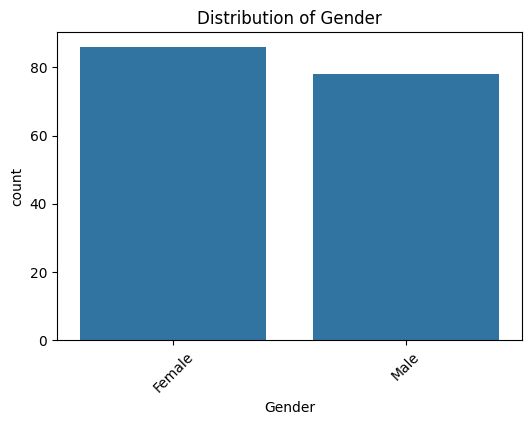

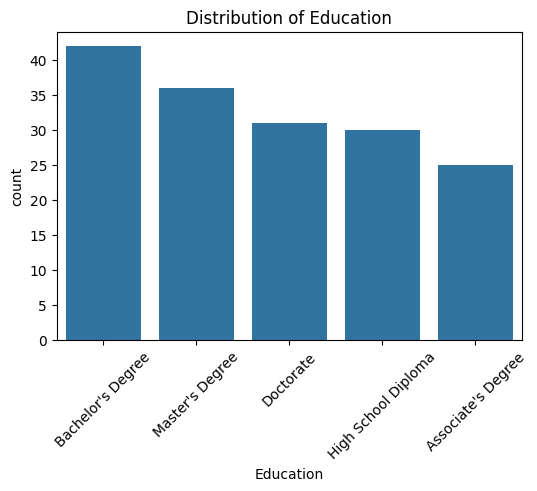

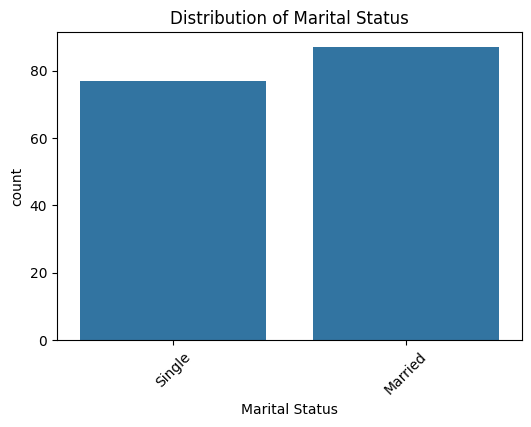

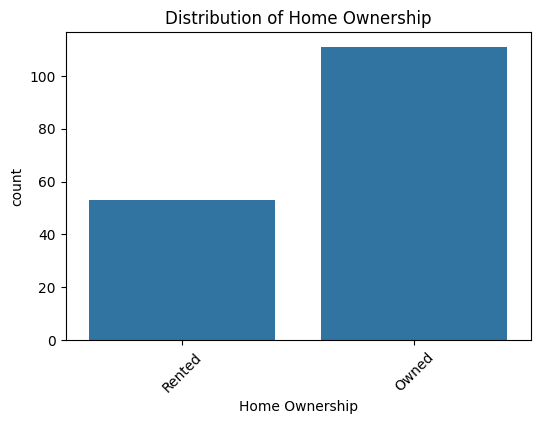

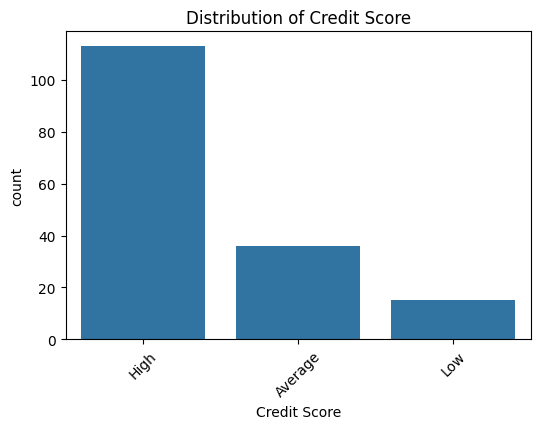

In [34]:
# Count plot for each categorical variable

for col in categorical_cols:

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

Insights for the variables:

**Gender**: The dataset shows a balanced distribution between men and women, with a slightly higher number of women.

**Education**: The most common education level among customers is a bachelor's degree.

**Marital Status**: Most customers are either married or single, with a slightly higher number of married individuals.

**Home Ownership**: This variable shows the proportion of customers who own a home or rent. A significant number of customers own their homes.

**Credit Score**: This variable shows the distribution between Low, Average, and High credit scores, with most customers having a high credit score.

**C) Outlier Treatment.**

Since Income contains extreme values, we apply the IQR method.

In [38]:
# Calculate quartiles
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

# Calculate interquartile range
IQR = Q3 - Q1

# Define limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(lower_limit, upper_limit)

-13750.0 176250.0


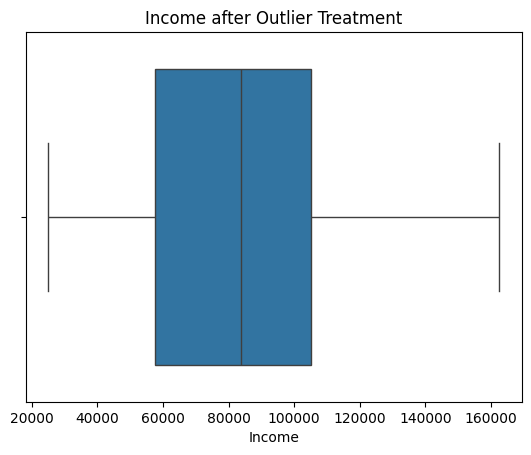

In [39]:
# Keep only values inside the acceptable range
df = df[(df['Income'] >= lower_limit) & (df['Income'] <= upper_limit)]

# Plot the new distribution
sns.boxplot(x=df['Income'])
plt.title("Income after Outlier Treatment")
plt.show()

**D) Bivariate Analysis:**




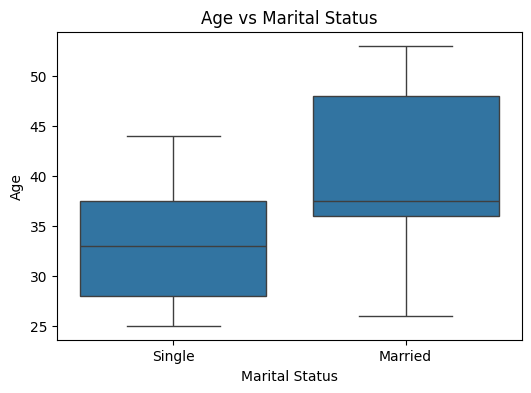

In [40]:
# Age vs Marital Status
# Married customers tend to be older, while single customers are generally younger.

# Compare age distribution by marital status

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marital Status', y='Age')

plt.title("Age vs Marital Status")
plt.show()


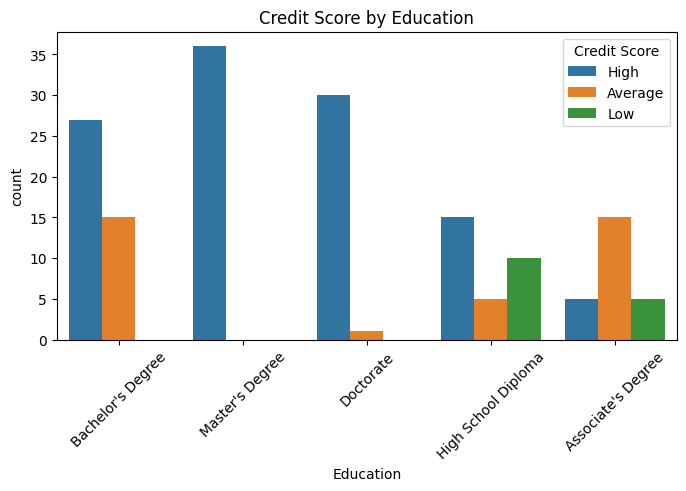

In [42]:
# Credit Score vs Education
# Higher levels of education tend to be associated with higher credit scores.
# Compare credit score distribution across education levels

plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Education', hue='Credit Score')

plt.xticks(rotation=45)
plt.title("Credit Score by Education")
plt.show()

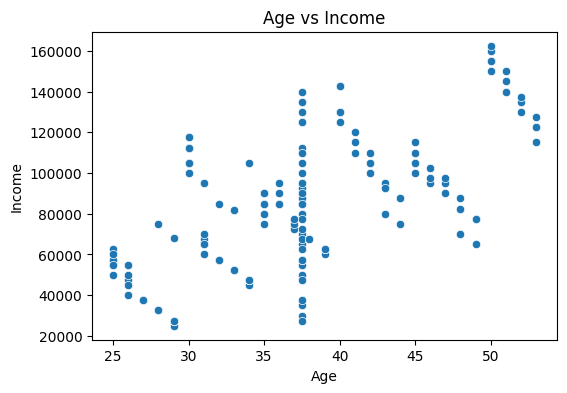

In [45]:
# Age vs Income
# There is a natural tendency for income to increase with age, especially during middle age.

# Scatterplot to see the relationship between age and income

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Age', y='Income')

plt.title("Age vs Income")
plt.show()

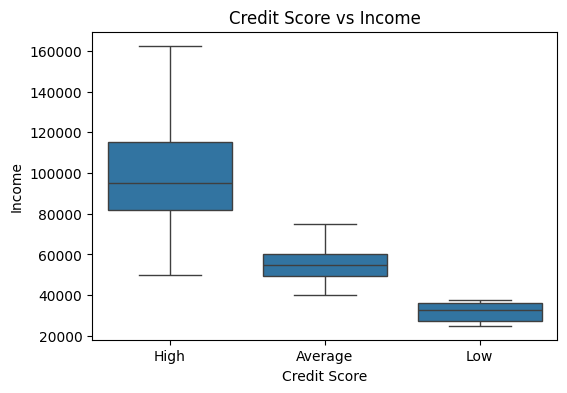

In [47]:
# Credit Score vs Income
# People with higher average incomes tend to have higher credit scores.

# Compare income across credit score groups

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Credit Score', y='Income')

plt.title("Credit Score vs Income")
plt.show()

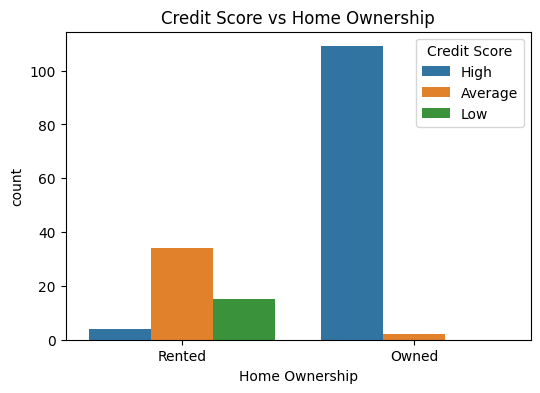

In [48]:
# Home Ownership vs Credit Score
# Yes, based on the charts, people who rent tend to have average or low credit scores, while people who own a home tend to have higher credit scores.

# Compare credit score distribution by housing type

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Home Ownership', hue='Credit Score')

plt.title("Credit Score vs Home Ownership")
plt.show()

**E) Additional Questions**



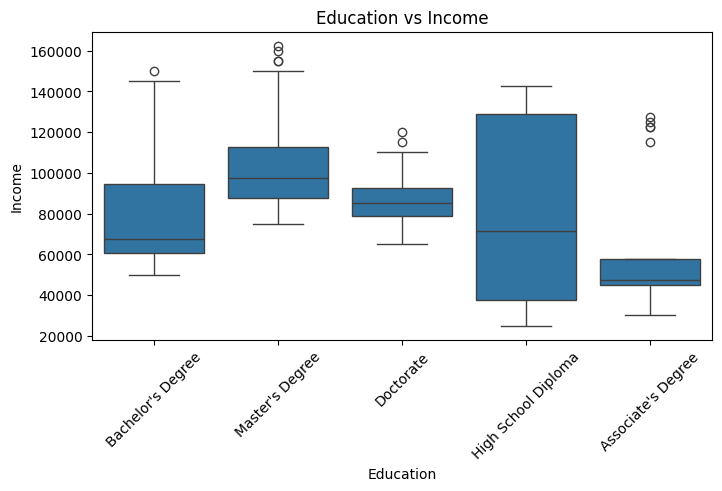

In [50]:
# Education vs Income
# Does education level affect income?

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Education', y='Income')

plt.xticks(rotation=45)
plt.title("Education vs Income")
plt.show()

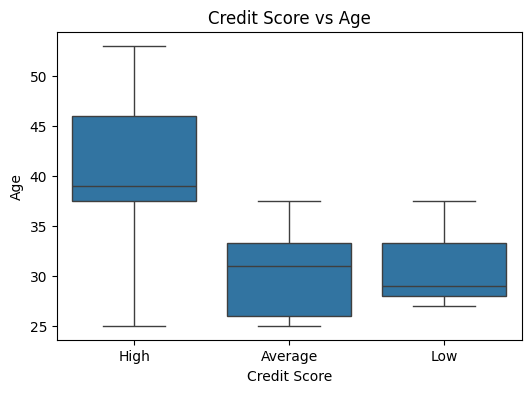

In [51]:
# Age vs Credit Score

# Do older individuals have higher credit scores?

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Credit Score', y='Age')

plt.title("Credit Score vs Age")
plt.show()

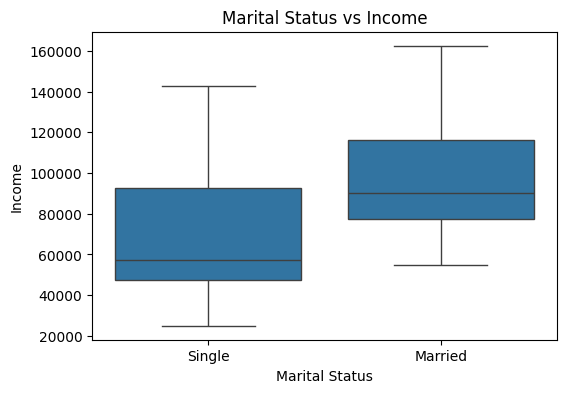

In [52]:
# Marital Status vs Income

# Does marital status influence income?

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Marital Status', y='Income')

plt.title("Marital Status vs Income")
plt.show()

# Step 3: Correlation Analysis


In [53]:
# Select only numerical variables
numerical_df = df.select_dtypes(include=['int64','float64'])

# Calculate correlation matrix
corr_matrix = numerical_df.corr()

corr_matrix

,Age,Income,Number of Children
Age,1.000000,0.620968,0.071032
Income,0.620968,1.000000,0.084547
Number of Children,0.071032,0.084547,1.000000


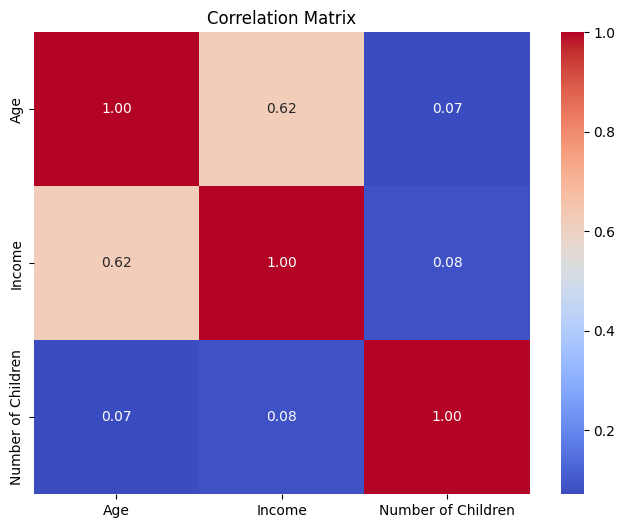

In [54]:
# Visualize correlation matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

Based on the correlation between the variables Age, Income, and Number of Children: Age and Income show a moderate positive correlation, as older individuals tend to have greater financial stability. Income and Number of Children show a low correlation, since the number of children does not necessarily depend on income. Age and Number of Children show a moderate correlation, as older individuals tend to have more children.

**Encoding Categorical Variables**

In [55]:
# Separate target variable
target = df['Credit Score']

# Separate predictor variables
X = df.drop('Credit Score', axis=1)

# Convert categorical variables into numerical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Display encoded dataset
X_encoded.head()

,Age,Income,Number of Children,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented
0,25.0,50000.0,0,False,True,False,False,False,True,True
1,30.0,100000.0,2,True,False,False,False,True,False,False
2,35.0,75000.0,1,False,False,True,False,False,False,False
3,40.0,125000.0,0,True,False,False,True,False,True,False
4,45.0,100000.0,3,False,True,False,False,False,False,False


In [56]:
# Combine encoded variables with the target

df_model = pd.concat([X_encoded, target], axis=1)

df_model.head()

,Age,Income,Number of Children,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree,Marital Status_Single,Home Ownership_Rented,Credit Score
0,25.0,50000.0,0,False,True,False,False,False,True,True,High
1,30.0,100000.0,2,True,False,False,False,True,False,False,High
2,35.0,75000.0,1,False,False,True,False,False,False,False,High
3,40.0,125000.0,0,True,False,False,True,False,True,False,High
4,45.0,100000.0,3,False,True,False,False,False,False,False,High


**Encode Target Variable.**

In [57]:
from sklearn.preprocessing import LabelEncoder

# Convert target categories into numbers
le = LabelEncoder()

df_model['Credit Score'] = le.fit_transform(df_model['Credit Score'])

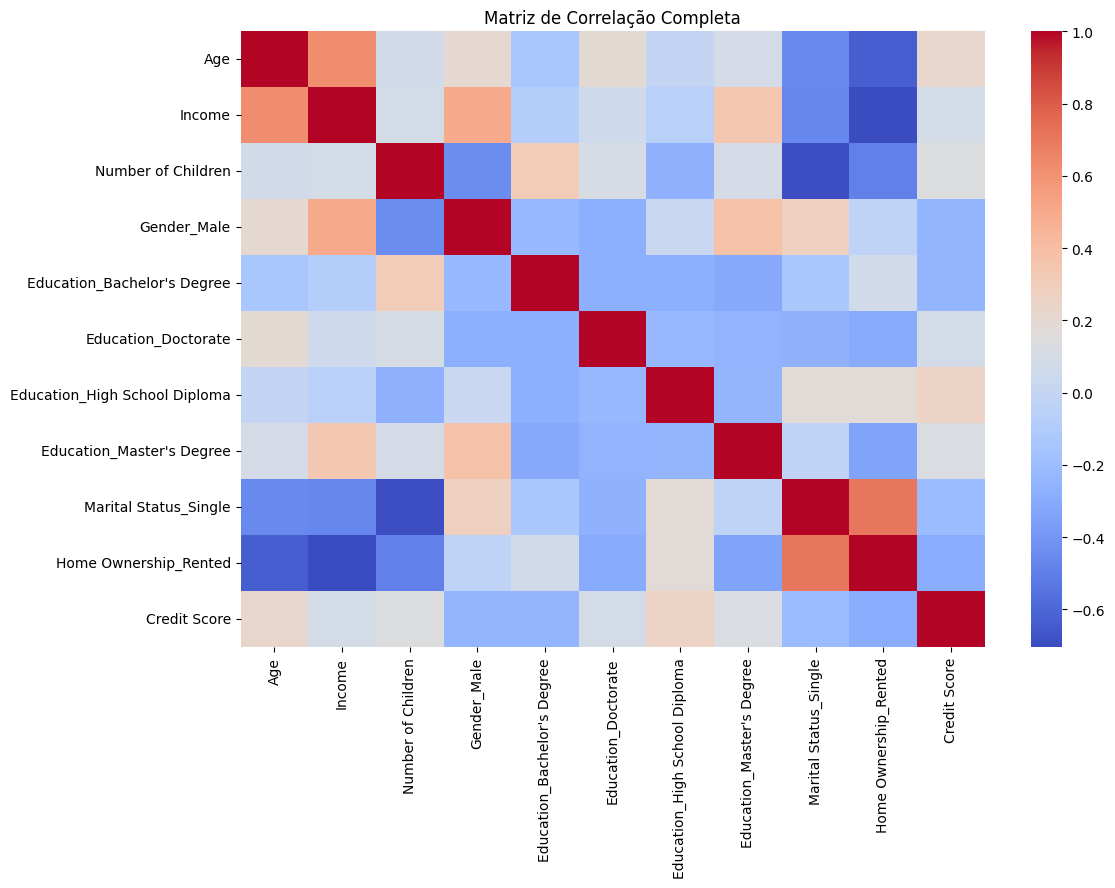

In [58]:
# Calculate the correlation matrix again

corr_matrix_full = df_model.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix_full,
    cmap='coolwarm',
    annot=False
)

plt.title("Matriz de Correlação Completa")
plt.show()

**Split Dataset into Training and Test Sets**

In [59]:
# Import the function used to split the dataset
from sklearn.model_selection import train_test_split

# Separate predictors (X) and target variable (y)

X = df_model.drop('Credit Score', axis=1)
y = df_model['Credit Score']

# Split the dataset into training and test sets
# 80% for training and 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42  # ensures reproducibility
)

# Check the shape of each dataset

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (131, 10)
Test set: (33, 10)


**Check if the Target Variable is Balanced**

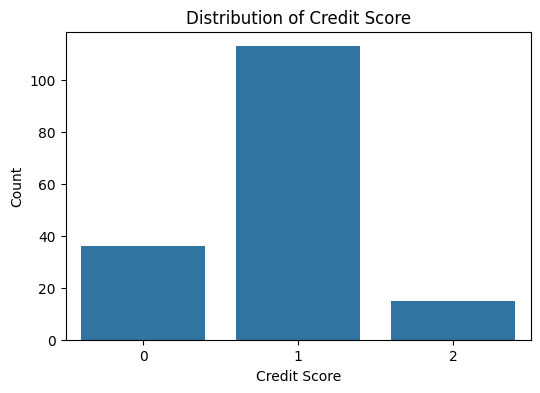

In [60]:
# Plot the distribution of the target variable

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

In [61]:
# Check the percentage of each class in the training data

y_train.value_counts(normalize=True)

,proportion
Credit Score,
1,0.687023
0,0.236641
2,0.076336


**Balancing the Target Variable with SMOTE**

In [62]:
# Import SMOTE
from imblearn.over_sampling import SMOTE

# Create the SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training dataset
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check the new class distribution
print(y_train_bal.value_counts())

Credit Score
1    90
0    90
2    90
Name: count, dtype: int64


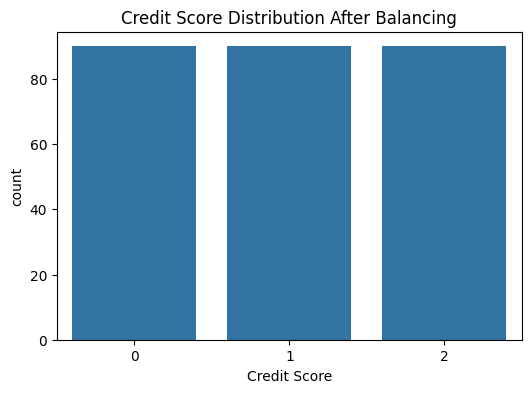

In [63]:
# Plot the new class distribution after balancing

plt.figure(figsize=(6,4))

sns.countplot(x=y_train_bal)

plt.title("Credit Score Distribution After Balancing")

plt.show()